In [34]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.utils import make_grid

In [35]:
LATENT_DIM = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_SAMPLES = 16
GRID_SIZE = 4

fixed_noise = torch.randn(NUM_SAMPLES,LATENT_DIM,device=DEVICE)

In [36]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128,3,4,2,1,bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0),z.size(1),1,1)
        return self.net(z)

In [37]:
def generate(G,fixed_noise,title,save_path=None):
    G.eval()
    with torch.no_grad():
        fake_images = G(fixed_noise).cpu()
    
    fake_images = (fake_images + 1) / 2
    fake_images = fake_images.clamp(0,1)

    grid = make_grid(fake_images,nrow=GRID_SIZE,padding=2)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title(title)
    if save_path is not None:
        plt.savefig(save_path,dpi=300,bbox_inches="tight")
    plt.show()

In [38]:
models = {
    "DCGAN":"checkpoints/dcgan_generator.pth",
    "SN-GAN":"checkpoints/sn_generator.pth",
    "DCGAN_Dropout":
    "checkpoints/dcgan_drop_generator.pth",
    "WGAN-GP":"checkpoints/wgan_generator.pth"
}

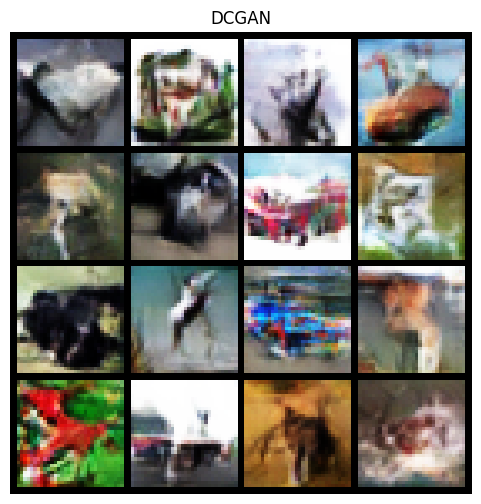

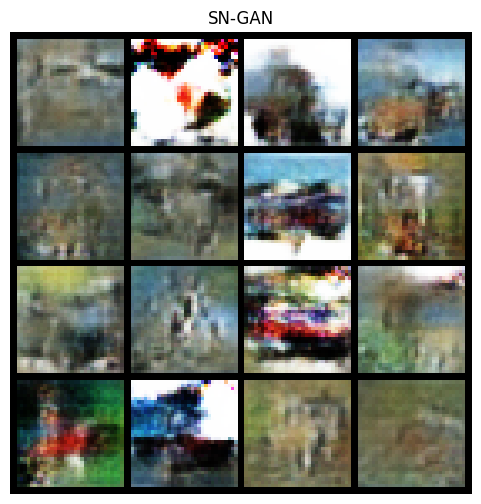

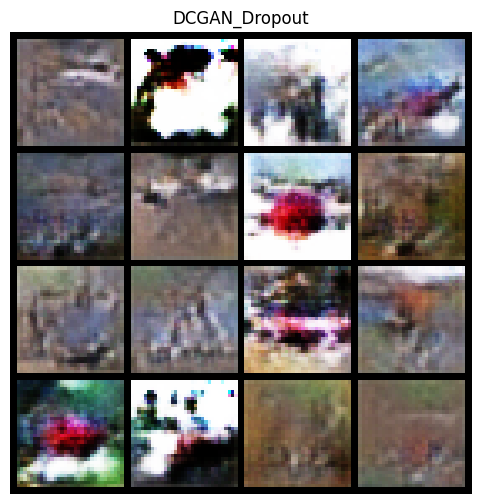

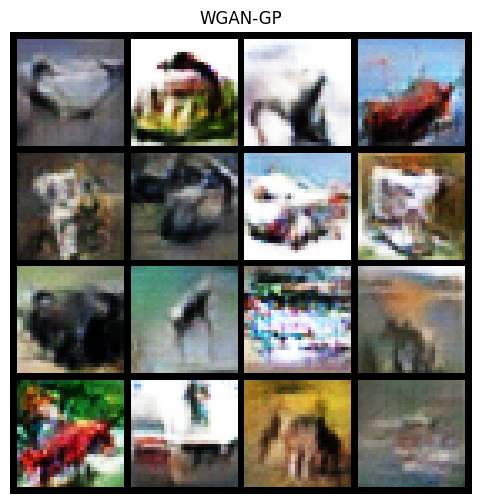

In [39]:
for name, path in models.items():
    G = DCGenerator(LATENT_DIM).to(DEVICE)
    G.load_state_dict(torch.load(path,map_location=DEVICE))
    generate(G,fixed_noise,title=name,save_path=f"samples/{name.replace(' ','_').replace('-','').lower()}.png")

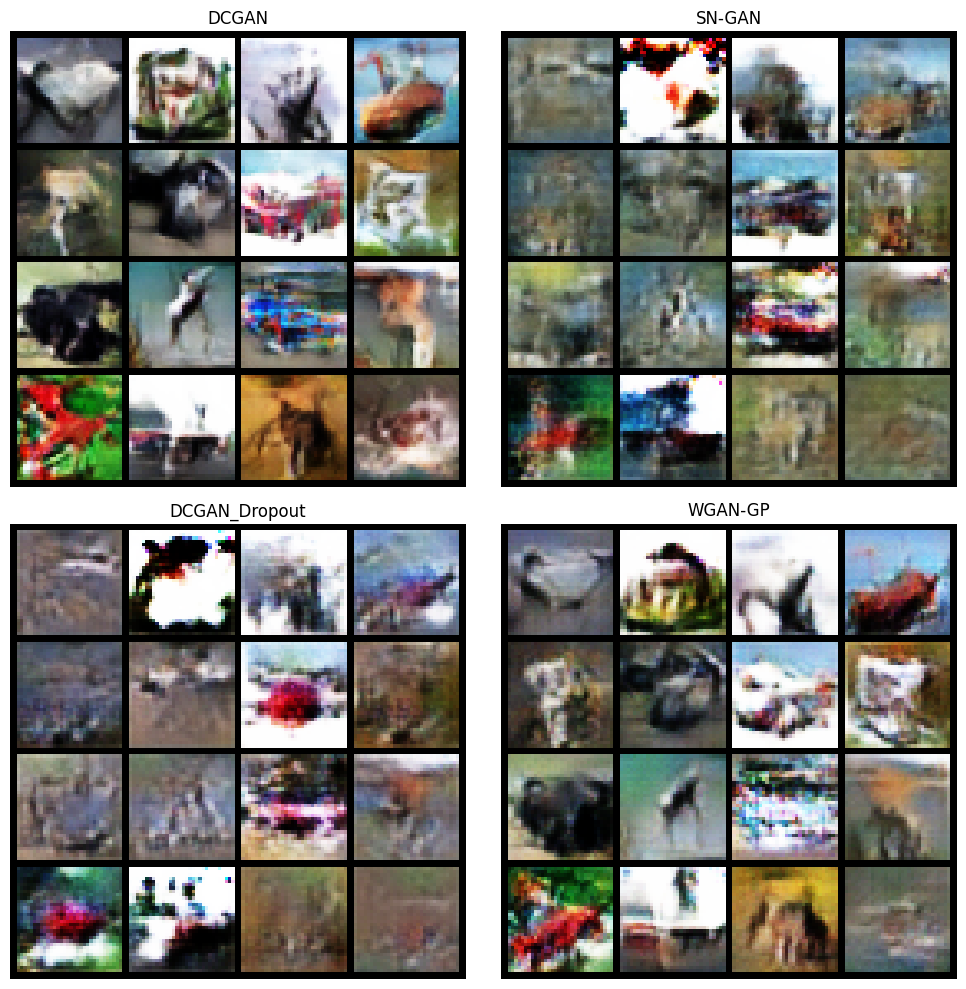

In [40]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
axes = axes.flatten()
for ax, (name, path) in zip(axes,models.items()):
    G = DCGenerator(LATENT_DIM).to(DEVICE)
    G.load_state_dict(torch.load(path,map_location=DEVICE))
    G.eval()
    with torch.no_grad():
        fake = G(fixed_noise).cpu()
    fake = (fake+1)/2
    fake = fake.clamp(0,1)
    grid = make_grid(fake,nrow=GRID_SIZE)
    ax.imshow(grid.permute(1,2,0))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.savefig("samples/comparison.png",dpi=300,bbox_inches="tight")
plt.show()

In [41]:
class Generator(nn.Module):

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024,3 * 32 * 32),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        x = x.view(-1,3,32,32)
        return x

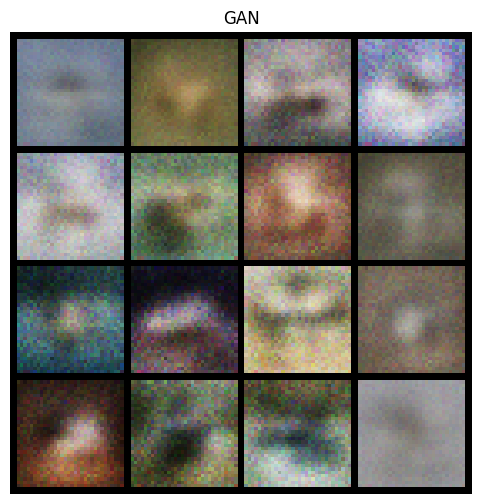

In [42]:
G = Generator(LATENT_DIM).to(DEVICE)
G.load_state_dict(torch.load("checkpoints/gan_generator.pth",map_location=DEVICE))
generate(G,fixed_noise,title="GAN",save_path=f"samples/{"GAN".replace(' ','_').replace('-','').lower()}.png")